In [ ]:
# Heart Disease Prediction
# This project aims to predict whether a patient has heart disease based on medical attributes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#load dataset:
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
#Data Cleaning:

In [ ]:
#check missing values
print(df.isnull().sum())

#Remove duplicates:
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Shape after cleaning: (920, 16)


In [ ]:
#Data Analysis:

In [ ]:
#Statistical summary of the dataset:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
#Data Preprocessing:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
#Correlation matrix to understand relationships between features
df.corr()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,1.000000,0.239301,0.280053,0.949062,-0.189430,0.052924,-0.376936,0.291005,0.477040,-0.466427,0.399679,0.049930,0.115371,0.061433,0.484673,0.273552
age,0.239301,1.000000,0.056889,0.235076,-0.076519,0.244253,-0.086234,0.125887,-0.013094,-0.365778,0.250938,0.258243,-0.222399,0.370416,-0.055761,0.339596
sex,0.280053,0.056889,1.000000,0.285734,-0.125933,0.001087,-0.197281,0.106900,0.074900,-0.179320,0.207197,0.103930,-0.033180,0.094123,0.148581,0.259342
dataset,0.949062,0.235076,0.285734,1.000000,-0.150334,0.021227,-0.416648,0.293678,0.456794,-0.414609,0.399767,0.053002,0.131545,0.030384,0.464508,0.276203
cp,-0.189430,-0.076519,-0.125933,-0.150334,1.000000,-0.023508,0.065279,-0.078563,-0.064280,0.300812,-0.241050,-0.181486,0.183725,-0.199452,-0.096112,-0.314518
trestbps,0.052924,0.244253,0.001087,0.021227,-0.023508,1.000000,0.092853,-0.011590,0.014034,-0.104899,0.152328,0.161908,-0.029471,0.093705,-0.004139,0.122291
chol,-0.376936,-0.086234,-0.197281,-0.416648,0.065279,0.092853,1.000000,-0.412369,-0.202552,0.236121,-0.029707,0.047734,0.087924,0.051606,-0.041309,-0.231547
fbs,0.291005,0.125887,0.106900,0.293678,-0.078563,-0.011590,-0.412369,1.000000,0.119873,-0.135389,0.004113,0.006027,-0.063412,0.193544,0.071754,0.186664
restecg,0.477040,-0.013094,0.074900,0.456794,-0.064280,0.014034,-0.202552,0.119873,1.000000,-0.170422,0.141274,-0.037788,0.171056,-0.114783,0.336679,0.034255
thalch,-0.466427,-0.365778,-0.179320,-0.414609,0.300812,-0.104899,0.236121,-0.135389,-0.170422,1.000000,-0.356439,-0.151174,0.170790,-0.264094,-0.173028,-0.366265


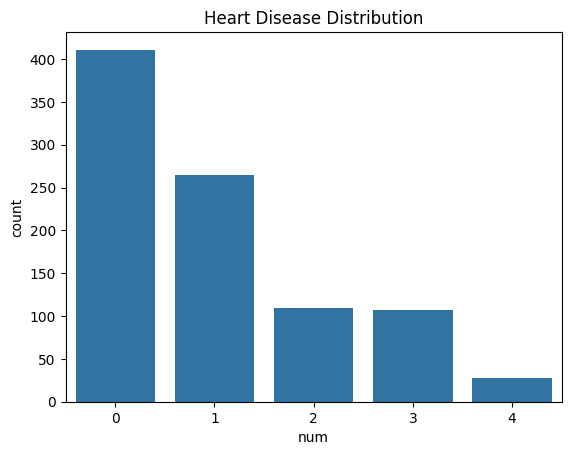

In [45]:
#Visualization 1
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
#The count plot shows the distribution of heart disease cases.  
#Most patients belong to category 0, which indicates no heart disease.  
#Fewer patients fall into higher severity levels (1 to 4).  
#This indicates that the dataset contains more healthy individuals compared to those with severe heart conditions.

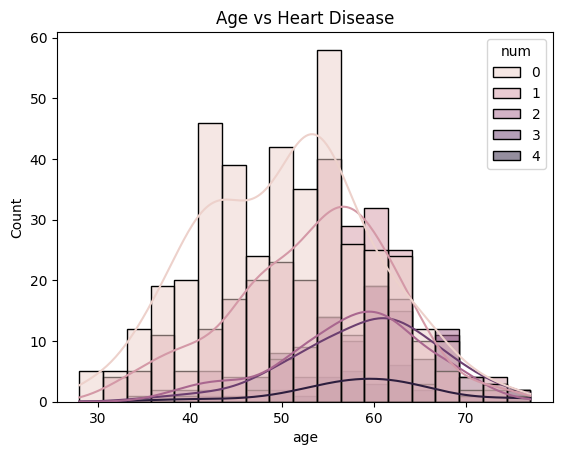

In [18]:
#Visualizations 2
sns.histplot(data=df, x='age', hue='num', kde=True)
plt.title("Age vs Heart Disease")
plt.show()

In [ ]:
#The histogram shows the relationship between age and heart disease.  
#It can be observed that middle-aged and older individuals are more likely to have heart disease.  
#Younger individuals have fewer cases.  
#This suggests that age is an important factor in predicting heart disease.

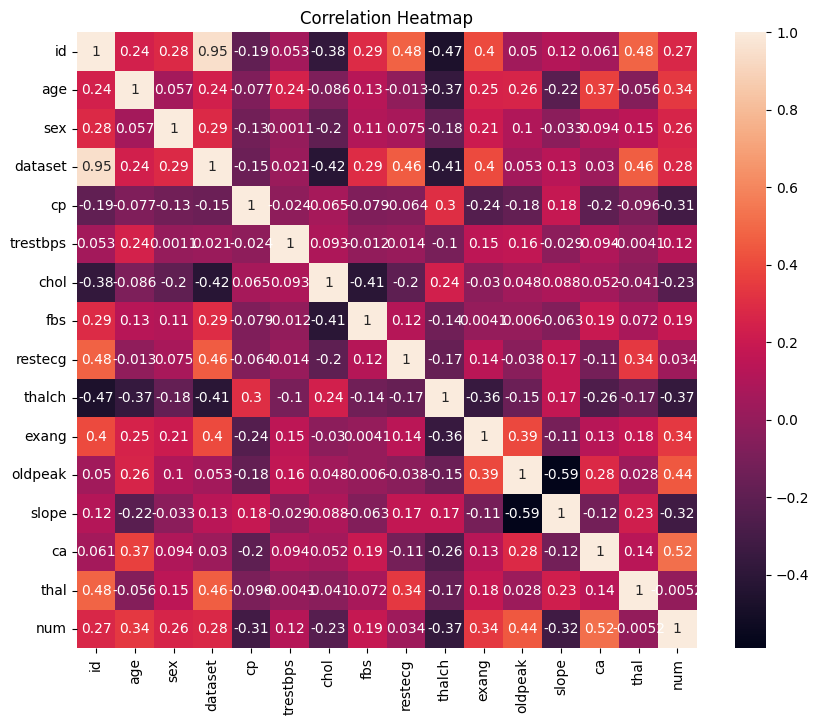

In [17]:
#Visualization 3
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#The correlation heatmap shows the relationships between different features in the dataset.  
#Some features like chest pain type (cp), maximum heart rate (thalch), and oldpeak show noticeable correlations with heart disease.  
#This helps in identifying important features for prediction.
#Both positive and negative correlations provide insights into feature importance.

In [ ]:
#Model Training

In [41]:
#Step-1: Define features and target
X = df.drop(['target', 'num'], axis=1)
y = df['target']

#Step-2: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Step-3: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
#Model-1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8206521739130435


In [43]:
#Model-2: Random Forest 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8913043478260869


In [ ]:
#Model Evaluation & Insights:

#Two machine learning models were used for prediction: Logistic Regression and Random Forest.
#Logistic Regression provides a baseline model, while Random Forest improves performance by combining multiple decision trees.
#Random Forest achieved better accuracy due to its ability to capture complex patterns in the dataset.
#Feature scaling was applied to improve the performance of Logistic Regression.
#The model can be used in healthcare systems to assist in early detection of heart disease.

In [ ]:
#Inference & Results:

#In this project, machine learning models were applied to predict the presence of heart disease based on patient health parameters.
#After preprocessing the dataset, including handling missing values and encoding categorical features, two models were trained: Logistic Regression and Random Forest.
#Logistic Regression provided a good baseline performance, while Random Forest achieved higher accuracy due to its ability to capture complex patterns and feature interactions.
#The results indicate that features such as age, chest pain type, cholesterol levels, and maximum heart rate play an important role in predicting heart disease.
#This model can be useful in healthcare systems to assist doctors in early diagnosis and risk assessment, ultimately improving patient care and decision-making.